In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [3]:
df = pd.read_csv("breakpoint_events.csv")
df.head()

,match_id,date,tourney_name,surface,tourney_level,pressure_level,round,player,opponent,set_no,...,match_winner,rank_diff,is_underdog,won_match,pbpp_3,pd_3,pbpp_6,pd_6,pbpp_12,pd_12
0,7031689,2015-01-05,Chennai,Hard,A,lower,R32,Gilles Muller,Edouard Roger-Vasselin,2.0,...,Gilles Muller,-70.0,0.0,1.0,1.000000,0.452736,0.833333,0.286070,0.833333,0.286070
1,7031689,2015-01-05,Chennai,Hard,A,lower,R32,Edouard Roger-Vasselin,Gilles Muller,3.0,...,Gilles Muller,70.0,1.0,0.0,0.666667,0.213930,0.500000,0.047264,0.333333,-0.119403
2,7031689,2015-01-05,Chennai,Hard,A,lower,R32,Edouard Roger-Vasselin,Gilles Muller,3.0,...,Gilles Muller,70.0,1.0,0.0,0.333333,-0.119403,0.333333,-0.119403,0.416667,-0.036070
3,7031689,2015-01-05,Chennai,Hard,A,lower,R32,Edouard Roger-Vasselin,Gilles Muller,3.0,...,Gilles Muller,70.0,1.0,0.0,0.000000,-0.452736,0.333333,-0.119403,0.416667,-0.036070
4,7031687,2015-01-05,Chennai,Hard,A,lower,R32,Robin Haase,Borna Coric,1.0,...,Borna Coric,-15.0,0.0,0.0,0.333333,-0.028369,0.166667,-0.195035,0.083333,-0.278369


In [4]:
print("Number of rows:", len(df))
print("Columns:")
print(df.columns)

Number of rows: 21978
Columns:
Index(['match_id', 'date', 'tourney_name', 'surface', 'tourney_level',
       'pressure_level', 'round', 'player', 'opponent', 'set_no', 'game_no',
       'point_index', 'player_rank', 'opponent_rank', 'baseline_win_rate',
       'match_winner', 'rank_diff', 'is_underdog', 'won_match', 'pbpp_3',
       'pd_3', 'pbpp_6', 'pd_6', 'pbpp_12', 'pd_12'],
      dtype='object')


## Project Overview

This notebook presents the April 14 milestone of my DSA210 term project.  
The goal is to examine whether professional tennis players experience a short-term performance decline after losing break points.

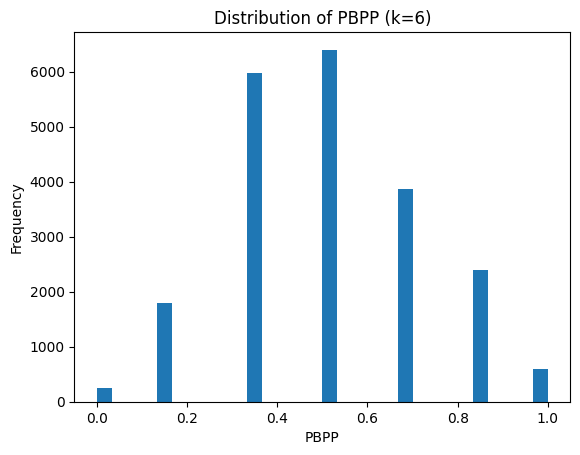

In [5]:
plt.hist(df["pbpp_6"], bins=30)
plt.title("Distribution of PBPP (k=6)")
plt.xlabel("PBPP")
plt.ylabel("Frequency")
plt.show()

### Interpretation of PBPP Distribution

PBPP values are mostly concentrated around the middle range, suggesting that after losing a break point, players often win a moderate share of the following points.  
This gives an initial view of how players perform immediately after high-pressure moments.

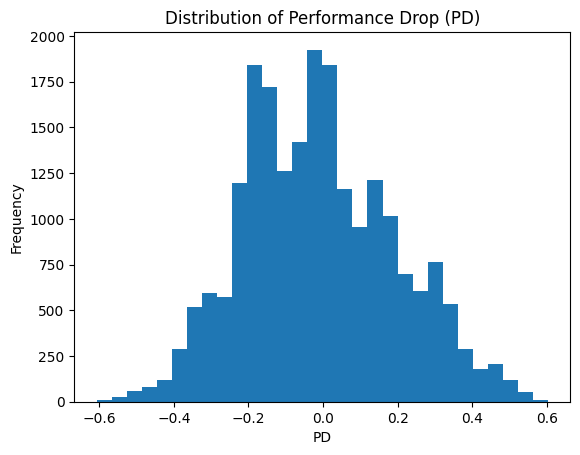

In [6]:
plt.hist(df["pd_6"], bins=30)
plt.title("Distribution of Performance Drop (PD)")
plt.xlabel("PD")
plt.ylabel("Frequency")
plt.show()

### Interpretation of Performance Drop

The PD distribution appears slightly shifted below zero.  
This suggests that players may perform somewhat worse than their usual baseline after losing a break point.

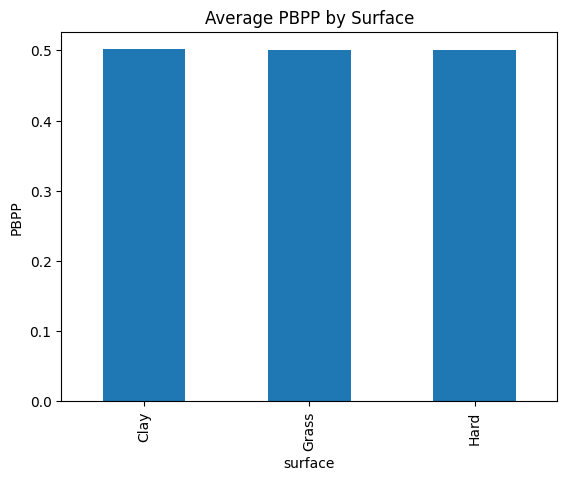

In [7]:
df.groupby("surface")["pbpp_6"].mean().plot(kind="bar")
plt.title("Average PBPP by Surface")
plt.ylabel("PBPP")
plt.show()

### Interpretation by Surface

This figure compares average PBPP across court surfaces.  
If visible differences exist, this may suggest that surface type affects how players recover after losing break points.

In [8]:
t_stat, p_value = stats.ttest_1samp(df["pd_6"], 0)
print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: nan
p-value: nan


### Hypothesis Test Result

The one-sample t-test evaluates whether the average performance drop differs from zero.  
A small p-value suggests that the drop is statistically significant, meaning players tend to perform worse after losing a break point.

In [9]:
for k in [3, 6, 12]:
    col = f"pd_{k}"
    t_stat, p_value = stats.ttest_1samp(df[col], 0)
    print(f"{col}: t-stat = {t_stat:.4f}, p-value = {p_value:.6f}")

pd_3: t-stat = nan, p-value = nan
pd_6: t-stat = nan, p-value = nan
pd_12: t-stat = nan, p-value = nan


### Robustness Across Different Windows

I also tested multiple window sizes (k=3, 6, 12) to see whether the result depends on a specific short-term horizon.  
If the effect remains significant across these values, this strengthens the reliability of the finding.

In [10]:
groups = [group["pd_6"].dropna().values for _, group in df.groupby("surface")]
f_stat, p_value = stats.f_oneway(*groups)
print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 0.0269134877637345
p-value: 0.9734454859535018


### Surface Comparison Test

ANOVA is used to test whether average performance drop differs across surfaces.  
If the p-value is small, this suggests that court surface plays a role in short-term post-break-point performance.

## Conclusion

This analysis provides evidence that losing a break point is associated with a short-term drop in performance.  
The effect is visible in the descriptive analysis and supported by hypothesis testing.  
Surface differences may also play a role, although this effect should be explored further with broader data coverage.